In [31]:
from dotenv import load_dotenv, find_dotenv
import os

# Force reload — bypasses any cached values
load_dotenv(find_dotenv("../.env"), override=True)

print("SUPABASE_URL:", os.getenv("SUPABASE_URL")[:30])
print("SUPABASE_KEY:", os.getenv("SUPABASE_KEY")[:30])

SUPABASE_URL: https://wvwcylvveasvgakzhppy.s
SUPABASE_KEY: sb_publishable_1YD6LZA643hkWCT


In [16]:
import sys
import os
import importlib.util

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

spec = importlib.util.spec_from_file_location("connection", "../src/database/connection.py")
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
engine = mod.get_engine()

from sqlalchemy import text
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, RocCurveDisplay

print("Connected OK")
print("PyTorch version:", torch.__version__)

python-dotenv could not parse statement starting at line 6


Connected OK
PyTorch version: 2.11.0+cpu


In [17]:
df = pd.read_csv("../data/processed/fan_6dB_id00_features.csv")

feature_cols = [c for c in df.columns if c not in ["label", "id", "clip_fk", "created_at"]]

X = df[feature_cols].values
y = (df["label"] == "abnormal").astype(int).values

# Scale
scaler = StandardScaler()
X_normal = X[y == 0]
X_normal_scaled = scaler.fit_transform(X_normal)
X_scaled = scaler.transform(X)

# Convert to tensors
X_normal_tensor = torch.FloatTensor(X_normal_scaled)
X_all_tensor    = torch.FloatTensor(X_scaled)

# DataLoader for training — batches of 32
train_loader = DataLoader(
    TensorDataset(X_normal_tensor),
    batch_size=32,
    shuffle=True
)

print(f"Training on {len(X_normal_tensor)} normal samples")
print(f"Input dimension: {X_normal_tensor.shape[1]}")

Training on 1011 normal samples
Input dimension: 34


In [18]:
from src.models.autoencoder import FanAutoencoder

# Init model
model_ae = FanAutoencoder(input_dim=X_normal_tensor.shape[1])
optimizer = torch.optim.Adam(model_ae.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

# Training loop
EPOCHS = 100
train_losses = []

model_ae.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    for (batch,) in train_loader:
        optimizer.zero_grad()
        reconstructed = model_ae(batch)
        loss = criterion(reconstructed, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} — Loss: {avg_loss:.6f}")

print("\nTraining complete")

Epoch  10/100 — Loss: 0.574037
Epoch  20/100 — Loss: 0.499351
Epoch  30/100 — Loss: 0.463580
Epoch  40/100 — Loss: 0.458344
Epoch  50/100 — Loss: 0.427117
Epoch  60/100 — Loss: 0.417734
Epoch  70/100 — Loss: 0.396022
Epoch  80/100 — Loss: 0.389236
Epoch  90/100 — Loss: 0.393185
Epoch 100/100 — Loss: 0.387175

Training complete


In [19]:
model_ae.eval()
errors = model_ae.reconstruction_error(X_all_tensor).numpy()

auc_ae = roc_auc_score(y, errors)
print(f"Autoencoder AUC-ROC: {auc_ae:.4f}")
print(f"Isolation Forest AUC-ROC: 0.8549")
print(f"Improvement: +{(auc_ae - 0.8549):.4f}")

Autoencoder AUC-ROC: 0.9196
Isolation Forest AUC-ROC: 0.8549
Improvement: +0.0647


c:\Users\Kavin sagar\mimii-anomaly-detection\.venv311\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


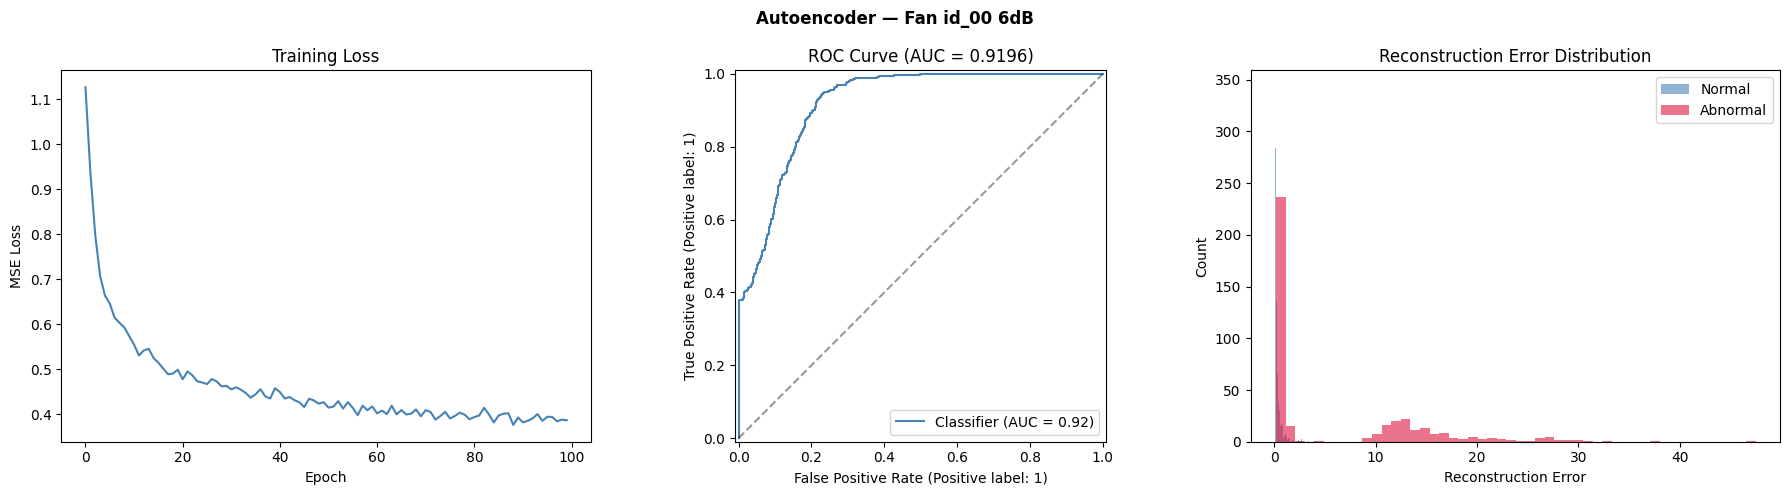

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Autoencoder — Fan id_00 6dB", fontweight="bold")

# Training loss curve
axes[0].plot(train_losses, color="steelblue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")

# ROC Curve
RocCurveDisplay.from_predictions(y, errors, ax=axes[1], color="steelblue")
axes[1].set_title(f"ROC Curve (AUC = {auc_ae:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)

# Score distribution
axes[2].hist(errors[y==0], bins=50, alpha=0.6, color="steelblue", label="Normal")
axes[2].hist(errors[y==1], bins=50, alpha=0.6, color="crimson", label="Abnormal")
axes[2].set_title("Reconstruction Error Distribution")
axes[2].set_xlabel("Reconstruction Error")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("../data/processed/autoencoder_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
import joblib
import torch
from sklearn.preprocessing import MinMaxScaler

# Save model
torch.save(model_ae.state_dict(), "../models_saved/autoencoder.pt")
joblib.dump(scaler, "../models_saved/scaler_autoencoder.joblib")
print("Autoencoder saved")

# Normalise errors to 0-1
score_scaler_ae = MinMaxScaler()
errors_normalized = score_scaler_ae.fit_transform(
    errors.reshape(-1, 1)
).flatten()

# Threshold — flag top 10% as anomalies
threshold = np.percentile(errors_normalized, 90)
y_pred_ae = (errors_normalized > threshold).astype(int)

# Store to SQL Server
with engine.connect() as conn:
    clip_rows = conn.execute(text("""
        SELECT id FROM audio_clips 
        WHERE machine_fk = 1 
        ORDER BY id
    """)).fetchall()

clip_ids = [row[0] for row in clip_rows]

with engine.begin() as conn:
    for clip_id, score, pred, true in zip(clip_ids, errors_normalized, y_pred_ae, y):
        conn.execute(text("""
            INSERT INTO predictions
                (clip_fk, model_name, anomaly_score, predicted_label, true_label)
            VALUES
                (:clip_fk, :model_name, :score, :predicted, :true_label)
        """), {
            "clip_fk":    clip_id,
            "model_name": "autoencoder",
            "score":      float(score),
            "predicted":  "abnormal" if pred == 1 else "normal",
            "true_label": "abnormal" if true == 1 else "normal"
        })

print(f"Stored {len(clip_ids)} autoencoder predictions to SQL Server")

Autoencoder saved


C:\Users\Kavin sagar\AppData\Local\Temp\ipykernel_45356\1650714263.py:21: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  with engine.connect() as conn:


Stored 1418 autoencoder predictions to SQL Server


In [32]:
from dotenv import load_dotenv, find_dotenv
import os
from supabase import create_client

load_dotenv(find_dotenv("../.env"), override=True)

supabase = create_client(
    os.getenv("SUPABASE_URL"),
    os.getenv("SUPABASE_KEY")
)
print("Supabase connected OK")

Supabase connected OK


In [30]:
# Fetch everything from SQL Server to sync
with engine.connect() as conn:
    rows = conn.execute(text("""
        SELECT 
            m.machine_type, m.machine_id, m.noise_level,
            ac.filename, ac.label,
            p.model_name, p.anomaly_score, p.predicted_label, p.true_label
        FROM predictions p
        JOIN audio_clips ac ON p.clip_fk = ac.id
        JOIN machines m ON ac.machine_fk = m.id
    """)).fetchall()

print(f"Fetched {len(rows)} predictions from SQL Server")

# Sync to Supabase in batches of 100
batch_size = 100
total = 0

for i in range(0, len(rows), batch_size):
    batch = rows[i:i+batch_size]
    data = [{
        "machine_type":    row[0],
        "machine_id":      row[1],
        "noise_level":     row[2],
        "filename":        row[3],
        "label":           row[4],
        "model_name":      row[5],
        "anomaly_score":   row[6],
        "predicted_label": row[7],
        "true_label":      row[8]
    } for row in batch]

    supabase.table("mimii_predictions").insert(data).execute()
    total += len(batch)
    print(f"Synced {total}/{len(rows)}")

print("Supabase sync complete")

Fetched 5672 predictions from SQL Server
Synced 100/5672
Synced 200/5672
Synced 300/5672
Synced 400/5672
Synced 500/5672
Synced 600/5672
Synced 700/5672
Synced 800/5672
Synced 900/5672
Synced 1000/5672
Synced 1100/5672
Synced 1200/5672
Synced 1300/5672
Synced 1400/5672
Synced 1500/5672
Synced 1600/5672
Synced 1700/5672
Synced 1800/5672
Synced 1900/5672
Synced 2000/5672
Synced 2100/5672
Synced 2200/5672
Synced 2300/5672
Synced 2400/5672
Synced 2500/5672
Synced 2600/5672
Synced 2700/5672
Synced 2800/5672
Synced 2900/5672
Synced 3000/5672
Synced 3100/5672
Synced 3200/5672
Synced 3300/5672
Synced 3400/5672
Synced 3500/5672
Synced 3600/5672
Synced 3700/5672
Synced 3800/5672
Synced 3900/5672
Synced 4000/5672
Synced 4100/5672
Synced 4200/5672
Synced 4300/5672
Synced 4400/5672
Synced 4500/5672
Synced 4600/5672
Synced 4700/5672
Synced 4800/5672
Synced 4900/5672
Synced 5000/5672
Synced 5100/5672
Synced 5200/5672
Synced 5300/5672
Synced 5400/5672
Synced 5500/5672
Synced 5600/5672
Synced 5672/5672